In [1]:
import pandas as pd

# keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,LabelEncoder

In [2]:
df = pd.read_csv("/content/metadata.csv")
df

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN


In [3]:
df = df.drop(columns=['start_time','battery_id','test_id','uid','filename'])
df

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.6743047446975208,NaN,NaN
1,impedance,24,NaN,0.05605783343888099,0.20097016584458333
2,charge,4,NaN,NaN,NaN
3,impedance,24,NaN,0.05319185850921101,0.16473399914864734
4,discharge,4,1.5243662105099023,NaN,NaN
...,...,...,...,...,...
7560,impedance,24,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,4,1.0201379996149256,NaN,NaN
7562,charge,4,NaN,NaN,NaN
7563,discharge,4,0.9907591663373165,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type                 7565 non-null   object
 1   ambient_temperature  7565 non-null   int64 
 2   Capacity             2794 non-null   object
 3   Re                   1956 non-null   object
 4   Rct                  1956 non-null   object
dtypes: int64(1), object(4)
memory usage: 295.6+ KB


In [5]:
# Convert 'Re', 'Rct', and 'Capacity' to numeric, invalid parsing will be set to NaN
df['Re'] = pd.to_numeric(df['Re'], errors='coerce')
df['Rct'] = pd.to_numeric(df['Rct'], errors='coerce')
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')


# Fill missing values in 'Re', 'Rct', and 'Capacity' with their respective means
df['Re'].fillna(df['Re'].mean(), inplace=True)
df['Rct'].fillna(df['Rct'].mean(), inplace=True)
df['Capacity'].fillna(df['Capacity'].mean(), inplace=True)


/tmp/ipykernel_2583/1074737519.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Re'].fillna(df['Re'].mean(), inplace=True)
/tmp/ipykernel_2583/1074737519.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [6]:
df

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.674305,-4.976500e+11,1.055903e+12
1,impedance,24,1.326543,5.605783e-02,2.009702e-01
2,charge,4,1.326543,-4.976500e+11,1.055903e+12
3,impedance,24,1.326543,5.319186e-02,1.647340e-01
4,discharge,4,1.524366,-4.976500e+11,1.055903e+12
...,...,...,...,...,...
7560,impedance,24,1.326543,9.680880e-02,1.548974e-01
7561,discharge,4,1.020138,-4.976500e+11,1.055903e+12
7562,charge,4,1.326543,-4.976500e+11,1.055903e+12
7563,discharge,4,0.990759,-4.976500e+11,1.055903e+12


In [9]:
df.isnull().sum()

,0
type,0
ambient_temperature,0
Capacity,0
Re,0
Rct,0


In [10]:
df['type'].value_counts()

,count
type,
charge,2815
discharge,2794
impedance,1956


In [12]:
label_encoder = LabelEncoder()
df['type'] = label_encoder.fit_transform(df['type'])
df.head()

,type,ambient_temperature,Capacity,Re,Rct
0,1,4,1.674305,-4.976500e+11,1.055903e+12
1,2,24,1.326543,5.605783e-02,2.009702e-01
2,0,4,1.326543,-4.976500e+11,1.055903e+12
3,2,24,1.326543,5.319186e-02,1.647340e-01
4,1,4,1.524366,-4.976500e+11,1.055903e+12


In [13]:
x = df.drop(columns=['ambient_temperature'])

y = df['ambient_temperature']

In [14]:
x

,type,Capacity,Re,Rct
0,1,1.674305,-4.976500e+11,1.055903e+12
1,2,1.326543,5.605783e-02,2.009702e-01
2,0,1.326543,-4.976500e+11,1.055903e+12
3,2,1.326543,5.319186e-02,1.647340e-01
4,1,1.524366,-4.976500e+11,1.055903e+12
...,...,...,...,...
7560,2,1.326543,9.680880e-02,1.548974e-01
7561,1,1.020138,-4.976500e+11,1.055903e+12
7562,0,1.326543,-4.976500e+11,1.055903e+12
7563,1,0.990759,-4.976500e+11,1.055903e+12


In [15]:
y

,ambient_temperature
0,4
1,24
2,4
3,24
4,4
...,...
7560,24
7561,4
7562,4
7563,4


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Display the shapes of the split data
print(f'X_train shape: {x_train.shape}')
print(f'X_test shape: {x_test.shape}')

X_train shape: (6052, 4)
X_test shape: (1513, 4)


In [21]:
# Initialize the StandardScaler
scaler = MinMaxScaler()


# Fit and transform the training data, then transform the test data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)


# Check the scaled data
print(f'Scaled X_train: \n{x_train_scaled[:5]}')
print(f'Scaled X_train: \n{X_test_scaled[:5]}')

Scaled X_train: 
[[1.00000000e+00 5.02450122e-01 9.99999999e-01 1.98111482e-10]
 [5.00000000e-01 4.55998175e-01 0.00000000e+00 1.00000000e+00]
 [5.00000000e-01 3.60527766e-02 0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 5.02450122e-01 0.00000000e+00 1.00000000e+00]
 [5.00000000e-01 5.35874070e-01 0.00000000e+00 1.00000000e+00]]
Scaled X_train: 
[[5.00000000e-01 0.00000000e+00 9.99486389e-01 5.13610683e-04]
 [5.00000000e-01 8.36946382e-01 9.99486389e-01 5.13610683e-04]
 [0.00000000e+00 6.58881373e-01 9.99486389e-01 5.13610683e-04]
 [5.00000000e-01 4.99361530e-01 9.99486389e-01 5.13610683e-04]
 [5.00000000e-01 5.10595053e-01 9.99486389e-01 5.13610683e-04]]


In [22]:
# Initialize the ANN model
model = Sequential()

# Input layer and first hidden layer with 64 units and ReLU activation
model.add(Dense(units=64, activation='relu', input_dim=x_train_scaled.shape[1]))

# Add Dropout layer with 0.2 rate (20% dropout)
model.add(Dropout(0.2))

# Second hidden layer with 32 units and ReLU activation
model.add(Dense(units=32, activation='relu'))

# Add another Dropout layer
model.add(Dropout(0.2))

# Output layer with 1 unit (for regression output), using a linear activation
model.add(Dense(units=1, activation='linear'))

# Compile the model with Adam optimizer and Mean Squared Error loss (for regression)
model.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(x_train_scaled, y_train, epochs=100, batch_size=32, validation_data=(x_test_scaled, y_test))

Epoch 1/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 294.2655 - val_loss: 113.7562
Epoch 2/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 116.1671 - val_loss: 113.9543
Epoch 3/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 114.9100 - val_loss: 118.6101
Epoch 4/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 110.5077 - val_loss: 123.1312
Epoch 5/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 108.2295 - val_loss: 136.6003
Epoch 6/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 107.2960 - val_loss: 125.2612
Epoch 7/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 104.8901 - val_loss: 140.6635
Epoch 8/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 104.2482 - val_loss: 151.6124
Epoch 9/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 101.2264 - val_loss: 152.1538
Epoch 10/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 101.1097 - val_loss: 139.4386
Epoch 11/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 100.4575 - val_loss: 146.60

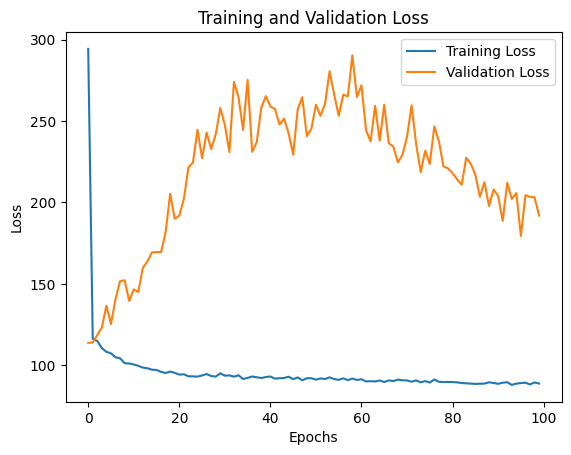

In [24]:
# Plot training and validation loss (optional)
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

In [25]:
# Evaluate the model on the test data
#mse = model.evaluate(X_test_scaled, y_test)
mse = model.evaluate(x_test_scaled, y_test)

# Print the Mean Squared Error (MSE)
print(f'Mean Squared Error on test set: {mse}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 191.9514
Mean Squared Error on test set: 191.95135498046875
